# Oil Price Change Point Detection - Interactive Notebook

This notebook provides a simplified, step-by-step workflow for detecting regime shifts in oil prices using Bayesian change point analysis.

---

## Setup

Import all necessary modules and configure display settings.

In [1]:
# Setup environment for PyTensor (PyMC compiler)
import os
import sys
from pathlib import Path

# Path to the newly installed MinGW compiler
mingw_path = r'C:\Users\Acer\AppData\Local\Microsoft\WinGet\Packages\BrechtSanders.WinLibs.POSIX.UCRT_Microsoft.Winget.Source_8wekyb3d8bbwe\mingw64\bin'
if mingw_path not in os.environ['PATH']:
    os.environ['PATH'] = mingw_path + os.pathsep + os.environ['PATH']

# Import modules
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add src to path if running from notebooks directory and package is not installed
sys.path.append(str(Path.cwd().parent / 'src'))

# Import our custom modules
from data import load_oil_data, clean_data, prepare_data_for_modeling
from eda import calculate_statistics, plot_time_series, plot_distribution, plot_volatility
from model import (build_changepoint_model, sample_model, 
                                        check_convergence, extract_results)
from visualization import plot_changepoint_results, plot_trace_diagnostics, plot_regime_comparison
from report import generate_report

# Configure matplotlib for inline display
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Environment configured and modules imported successfully!")

✓ Environment configured and modules imported successfully!


---

## Step 1: Load and Prepare Data

Load the oil price dataset and prepare it for analysis.

In [2]:
# Define data path
data_path = Path('../data/processed_data.csv')




# Load data
print("Loading oil price data...")
if not data_path.exists():
    print(f"Error: Data file not found at {data_path.absolute()}")
else:
    df = load_oil_data(data_path)
    print(f"✓ Loaded {len(df)} records\n")

    # Display first few rows
    print("First 5 rows:")
    display(df.head())

Loading oil price data...
✓ Loaded 9011 records

First 5 rows:


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
# Clean data
print("Cleaning data...")
df_clean = clean_data(df)
print(f"✓ Cleaned data: {len(df_clean)} records")

# Prepare for modeling
print("\nPreparing data for modeling...")
data_dict = prepare_data_for_modeling(df_clean)

print(f"\n{'='*50}")
print("DATA SUMMARY")
print(f"{'='*50}")
print(f"Observations: {data_dict['n_days']}")
print(f"Date range: {data_dict['dates'][0]} to {data_dict['dates'][-1]}")
print(f"Price range: ${data_dict['oil_prices'].min():.2f} - ${data_dict['oil_prices'].max():.2f}")
print(f"Mean: ${data_dict['historical_mean']:.2f}")
print(f"Std Dev: ${data_dict['historical_std']:.2f}")
print(f"{'='*50}")

Cleaning data...
✓ Cleaned data: 9011 records

Preparing data for modeling...

DATA SUMMARY
Observations: 9011
Date range: 1987-05-20T00:00:00.000000000 to 2022-11-14T00:00:00.000000000
Price range: $9.10 - $143.95
Mean: $48.42
Std Dev: $32.86


---

## Step 2: Exploratory Data Analysis

Visualize the data to understand trends, distributions, and volatility patterns.

In [4]:
# Calculate statistics
stats = calculate_statistics(df_clean)


DESCRIPTIVE STATISTICS
Mean:       $48.42
Median:     $38.57
Std Dev:    $32.86
Min:        $9.10
Max:        $143.95
Range:      $134.85
Q25:        $19.05
Q75:        $70.09


Time Series Plot:


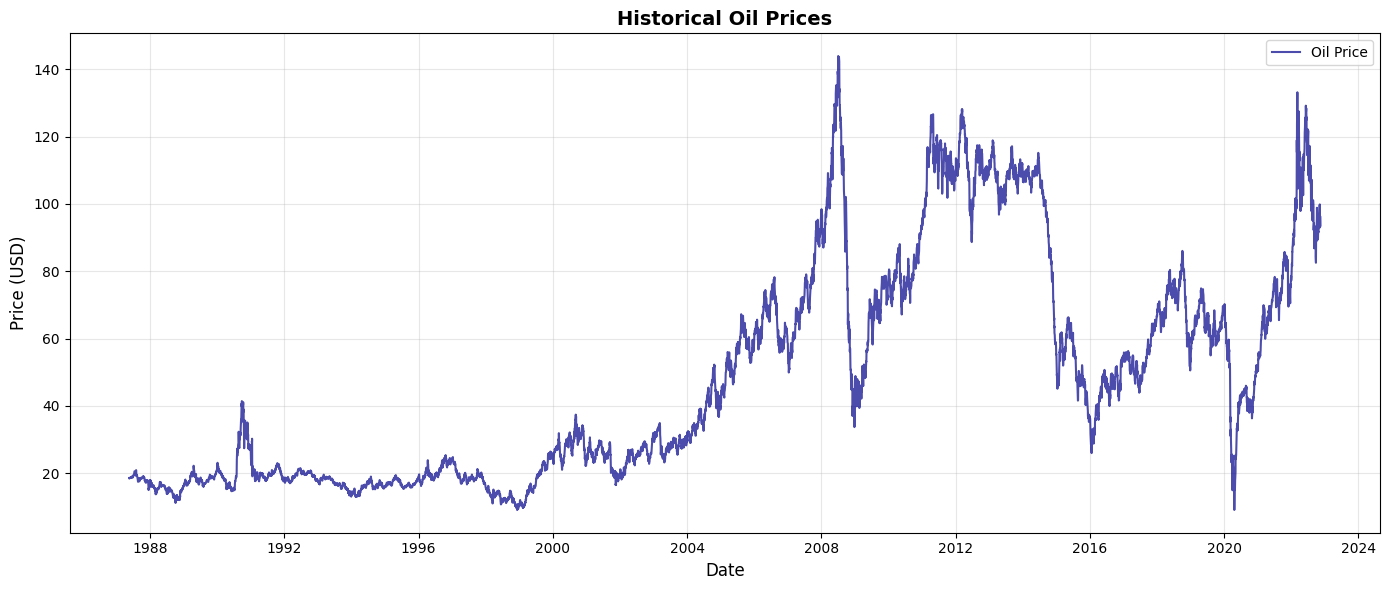

In [5]:
# Plot time series
print("Time Series Plot:")
plot_time_series(df_clean)

Price Distribution:


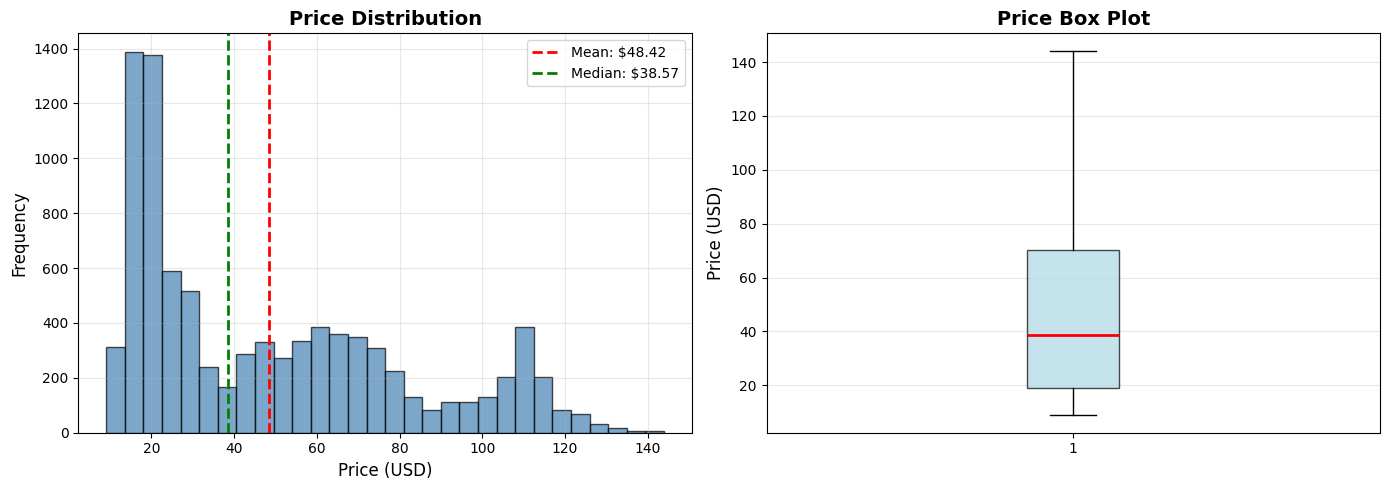

In [6]:
# Plot distribution
print("Price Distribution:")
plot_distribution(df_clean)

Volatility Analysis:


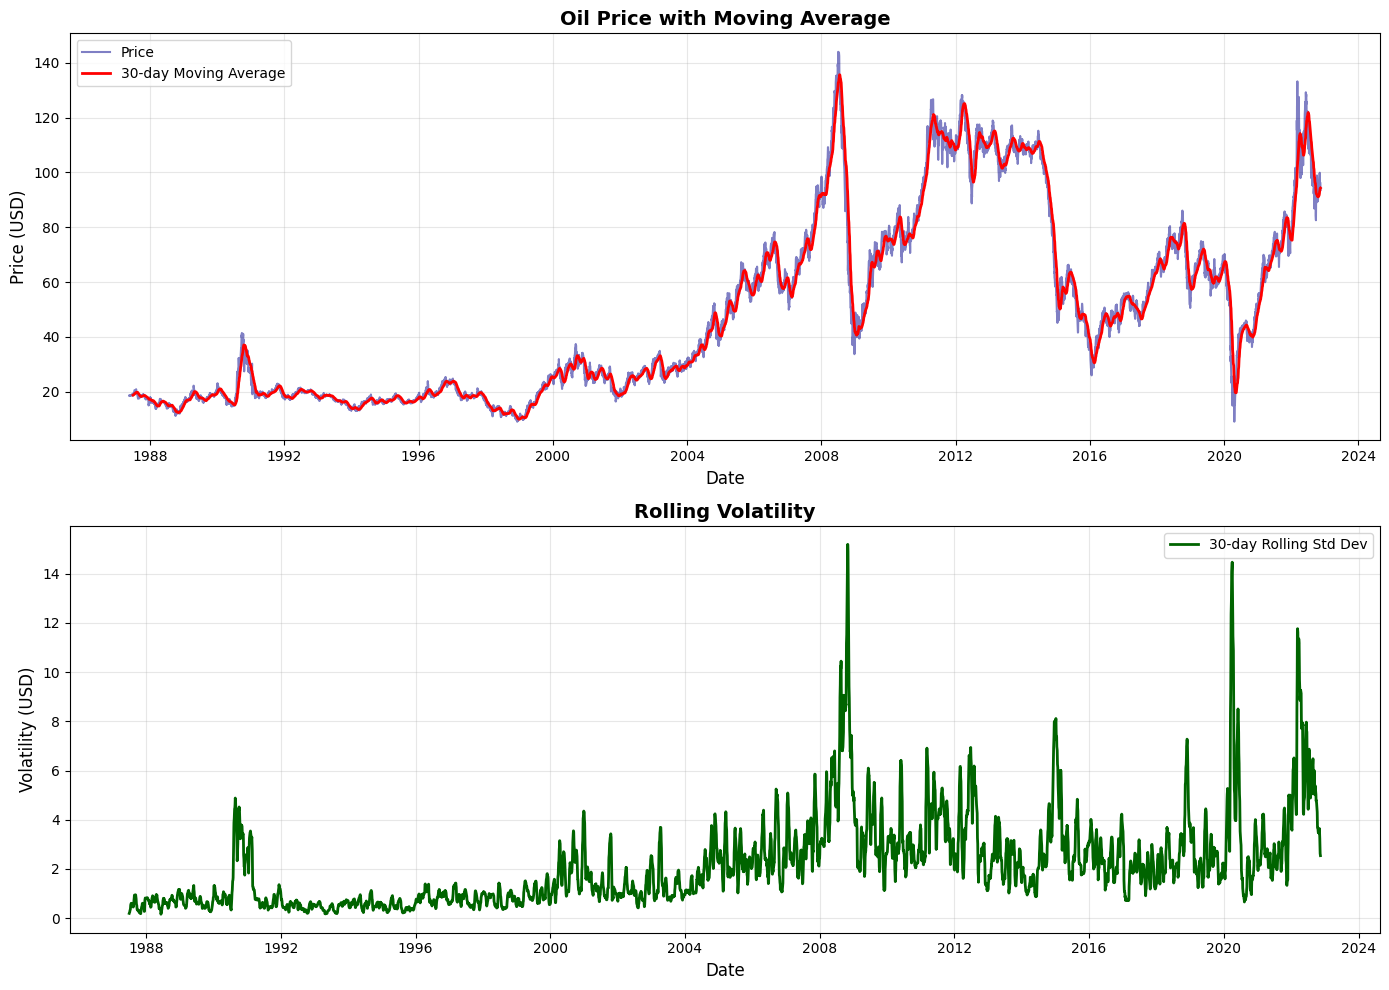

In [7]:
# Plot volatility
print("Volatility Analysis:")
plot_volatility(df_clean, window=30)

---

## Step 3: Build Bayesian Change Point Model

Construct the Bayesian model with appropriate priors and likelihood.

In [8]:
print("Building Bayesian change point model...\n")

model = build_changepoint_model(
    data_dict['oil_prices'],
    data_dict['historical_mean'],
    data_dict['historical_std']
)

print("✓ Model built successfully!")
print("\nModel Structure:")
print("  - Change point (τ): DiscreteUniform(0, n_days-1)")
print("  - Price before (μ₁): Normal(historical_mean, 20)")
print("  - Price after (μ₂): Normal(historical_mean, 20)")
print("  - Volatility before (σ₁): HalfNormal(10)")
print("  - Volatility after (σ₂): HalfNormal(10)")

Building Bayesian change point model...

✓ Model built successfully!

Model Structure:
  - Change point (τ): DiscreteUniform(0, n_days-1)
  - Price before (μ₁): Normal(historical_mean, 20)
  - Price after (μ₂): Normal(historical_mean, 20)
  - Volatility before (σ₁): HalfNormal(10)
  - Volatility after (σ₂): HalfNormal(10)




## Step 4: Run MCMC Sampling

Sample from the posterior distribution using MCMC.



In [9]:
# Run MCMC sampling
trace = sample_model(
    model, 
    draws=1000,      # Number of samples per chain
    tune=1000,       # Tuning iterations
    chains=4,        # Number of chains
    random_seed=42   # For reproducibility
)


RUNNING MCMC SAMPLING


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [mu_before, mu_after, sigma_before, sigma_after]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 92 seconds.



Generating posterior predictive samples...

DONE: Sampling complete!


---

## Step 5: Check Convergence

Verify that MCMC sampling converged properly.

In [10]:
# Check convergence
convergence_ok = check_convergence(trace)

if convergence_ok:
    print("\n✅ MCMC sampling converged successfully!")
    print("Results are reliable and can be interpreted with confidence.")
else:
    print("\n⚠️ WARNING: Convergence issues detected!")
    print("Consider increasing draws or tune parameters.")


Convergence Summary:
                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_before     20.315  0.094  20.153   20.507      0.001    0.001    4256.0   
mu_after      73.773  0.391  73.067   74.526      0.006    0.005    4623.0   
sigma_before   5.514  0.074   5.377    5.652      0.001    0.001    4916.0   
sigma_after   25.874  0.274  25.369   26.391      0.004    0.004    5516.0   

              ess_tail  r_hat  
mu_before       3184.0    1.0  
mu_after        3327.0    1.0  
sigma_before    3214.0    1.0  
sigma_after     3143.0    1.0  

v Convergence looks GOOD!

✅ MCMC sampling converged successfully!
Results are reliable and can be interpreted with confidence.


---

## Step 6: Extract Results

Extract the detected change point and price level estimates.

In [11]:
# Extract results
results = extract_results(trace, data_dict['dates'])


CHANGE POINT DETECTION RESULTS
Change point: 2004-03-01T00:00:00.000000000
95% CI: 2004-02-20T00:00:00.000000000 to 2004-04-19T00:00:00.000000000
Shift: $20.32 to $73.77 (+263.1%)


In [12]:
# Display key findings
print("\n" + "="*60)
print(" "*15 + "KEY FINDINGS")
print("="*60)

print(f"\n🎯 DETECTED CHANGE POINT: {results['change_date']}")
print(f"\n📊 95% Credible Interval:")
print(f"   {results['date_lower']} to {results['date_upper']}")

print(f"\n💰 PRICE ANALYSIS:")
print(f"   Before: ${results['mu_before_mean']:.2f} ± ${results['mu_before_std']:.2f}")
print(f"   After:  ${results['mu_after_mean']:.2f} ± ${results['mu_after_std']:.2f}")
print(f"   Change: ${results['price_change']:.2f} ({results['price_change_pct']:+.1f}%)")

print(f"\n📈 VOLATILITY:")
print(f"   Before: ${results['sigma_before_mean']:.2f}")
print(f"   After:  ${results['sigma_after_mean']:.2f}")

print("\n" + "="*60)


               KEY FINDINGS

🎯 DETECTED CHANGE POINT: 2004-03-01T00:00:00.000000000

📊 95% Credible Interval:
   2004-02-20T00:00:00.000000000 to 2004-04-19T00:00:00.000000000

💰 PRICE ANALYSIS:
   Before: $20.32 ± $0.09
   After:  $73.77 ± $0.39
   Change: $53.46 (+263.1%)

📈 VOLATILITY:
   Before: $5.51
   After:  $25.87



---

## Step 7: Visualize Results

Create comprehensive visualizations of the detected change point.

Change Point Detection Results:


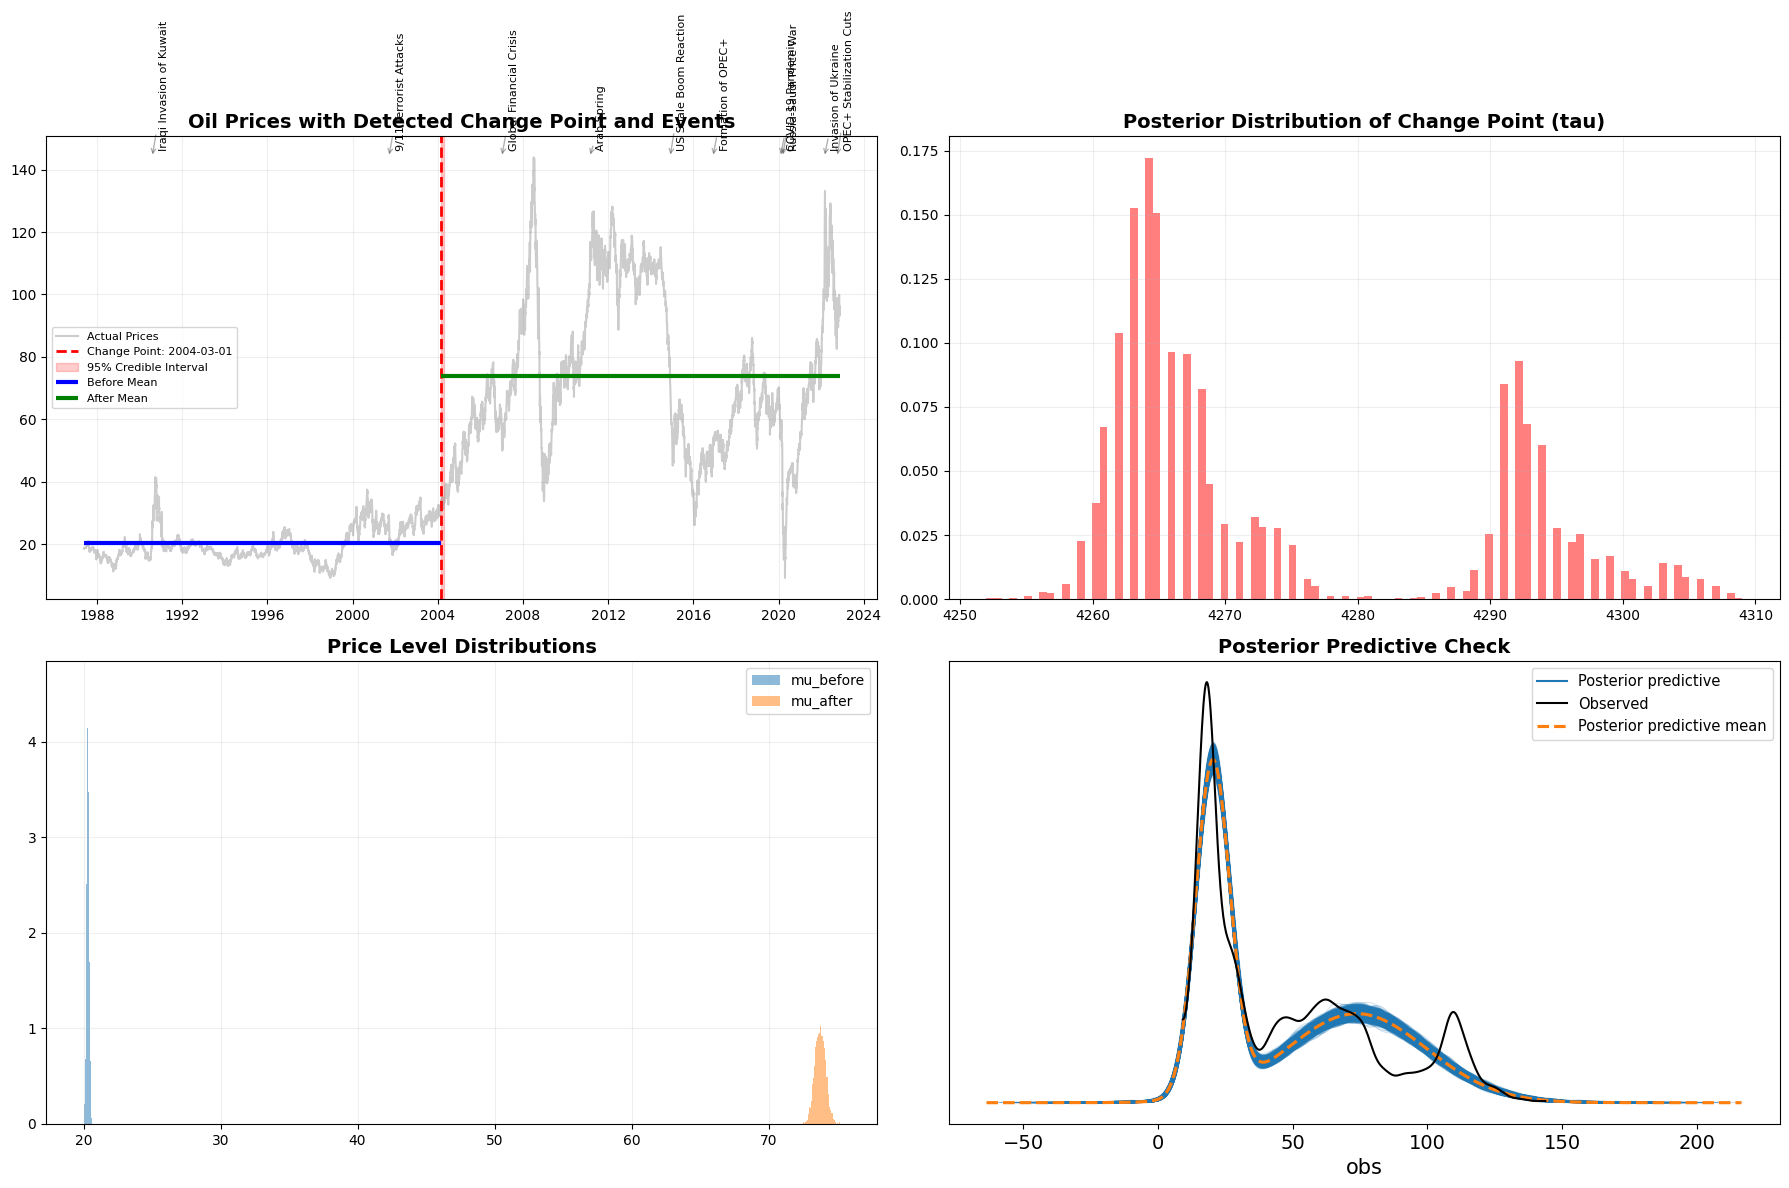

In [13]:
# Main results dashboard
events_df = pd.read_csv('../Event.csv')
print("Change Point Detection Results:")
plot_changepoint_results(
    data_dict['dates'],
    data_dict['oil_prices'],
    results,
    trace,
    events_df
)

MCMC Trace Diagnostics:


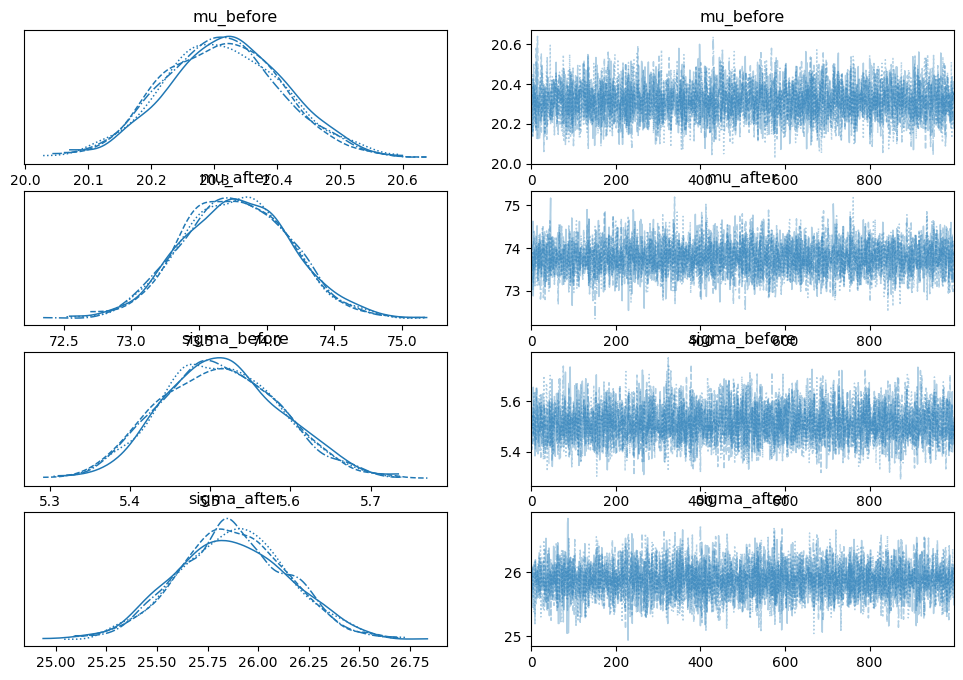

In [14]:
# Trace diagnostics
print("MCMC Trace Diagnostics:")
plot_trace_diagnostics(trace)

Regime Comparison:


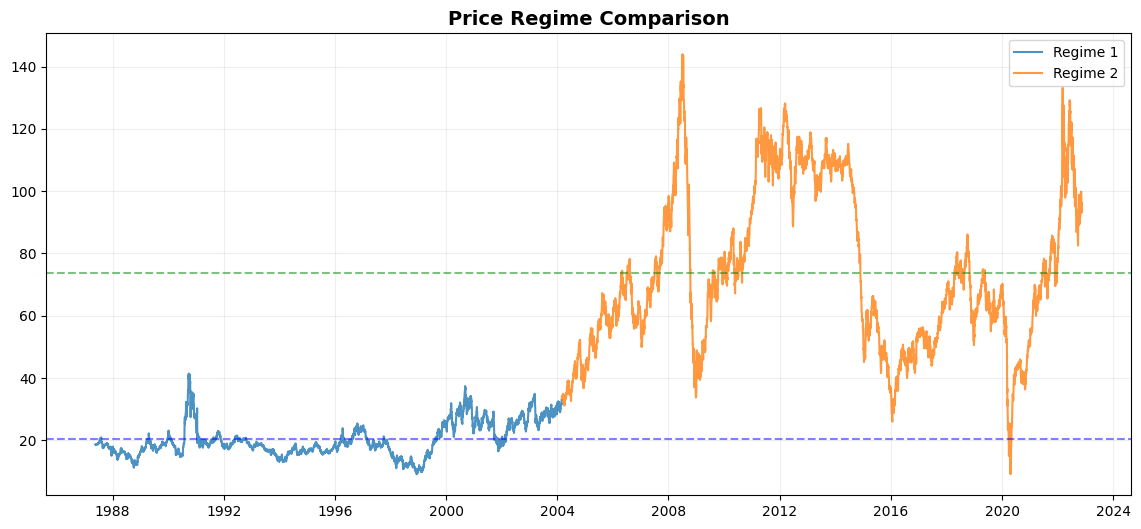

In [15]:
# Regime comparison
print("Regime Comparison:")
plot_regime_comparison(
    data_dict['dates'],
    data_dict['oil_prices'],
    results
)

---

## Step 9: Interpretation

Interpret the results in context of historical events.

In [17]:
# Interpretation helper
change_date = results['change_date']
change_year = change_date.astype('datetime64[Y]').astype(int) + 1970
change_month = change_date.astype('datetime64[M]').astype(int) % 12 + 1

print("\n" + "="*60)
print(" "*20 + "INTERPRETATION")
print("="*60)

print(f"\nDetected change point: {change_date}")
print(f"Year: {change_year}, Month: {change_month}")

# Check for known events
if change_year == 2020 and change_month in [2, 3, 4]:
    print("\n🔍 HISTORICAL CONTEXT:")
    print("   This aligns with the COVID-19 pandemic onset (early 2020).")
    print("   The pandemic caused a dramatic collapse in oil demand and prices.")
    print("   Oil prices fell from ~$65 to below $25 in March-April 2020.")

print("\n💡 RECOMMENDATIONS:")
print("   1. Validate against historical oil market events")
print("   2. Consider geopolitical factors (OPEC, wars, sanctions)")
print("   3. Analyze supply/demand dynamics around the change point")
print("   4. Use detected regimes for forecasting future prices")
print("\n" + "="*60)


                    INTERPRETATION

Detected change point: 2004-03-01T00:00:00.000000000
Year: 2004, Month: 3

💡 RECOMMENDATIONS:
   1. Validate against historical oil market events
   2. Consider geopolitical factors (OPEC, wars, sanctions)
   3. Analyze supply/demand dynamics around the change point
   4. Use detected regimes for forecasting future prices



---

## Summary

### What We Accomplished:

1. ✅ Loaded and cleaned oil price data
2. ✅ Performed exploratory data analysis
3. ✅ Built Bayesian change point model
4. ✅ Ran MCMC sampling with convergence checks
5. ✅ Detected regime shift with credible intervals
6. ✅ Generated comprehensive visualizations
7. ✅ Created detailed analysis report

### Next Steps:

- Review the generated report in `outputs/analysis_report.md`
- Validate findings against historical events
- Try with your own oil price data
- Extend to multiple change points if needed

---

## Optional: Save All Visualizations

Run this cell to save all plots to the outputs directory.

Saving all visualizations...

Saved time series plot to ..\outputs\eda_time_series.png


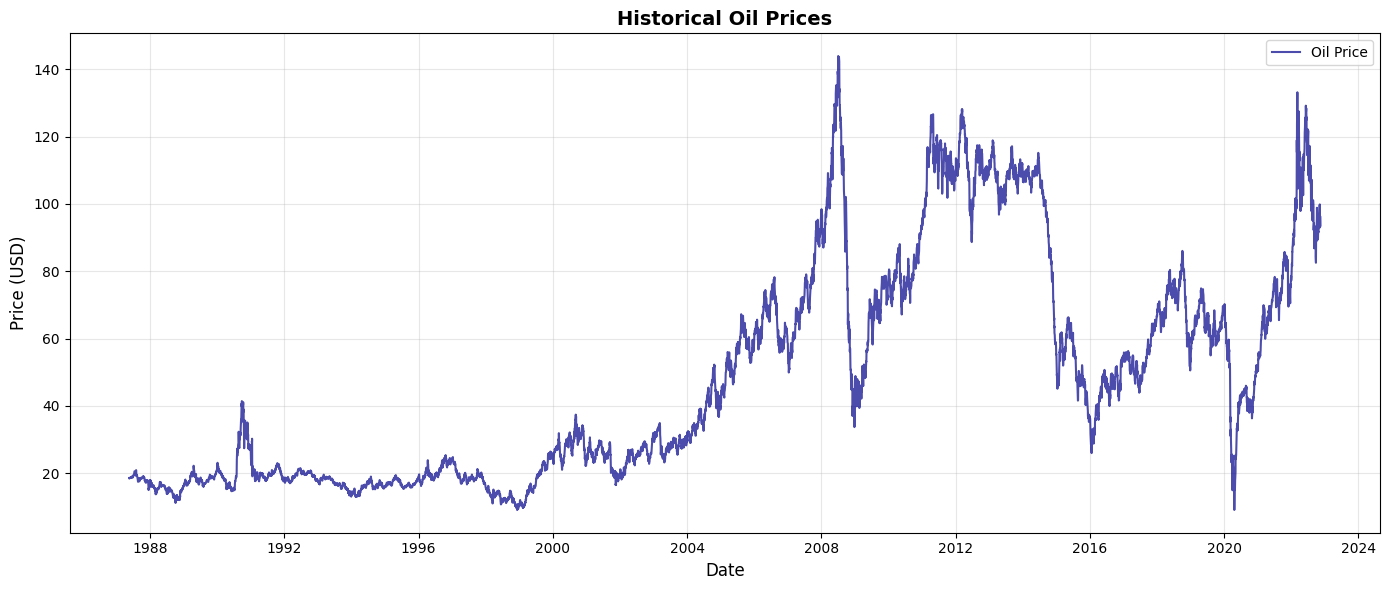

Saved distribution plot to ..\outputs\eda_distribution.png


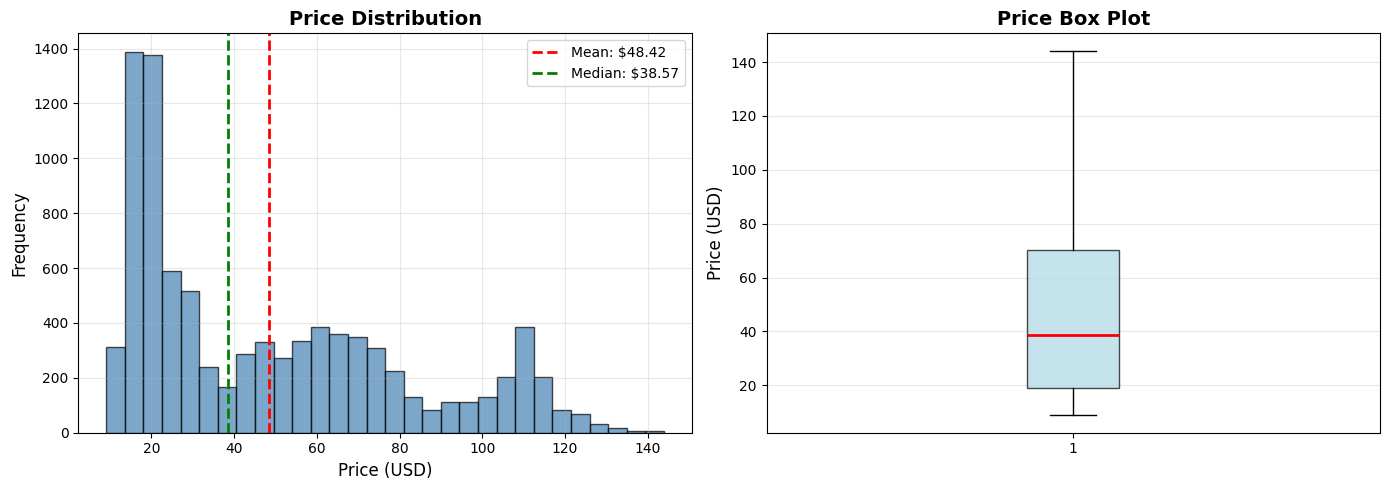

Saved volatility plot to ..\outputs\eda_volatility.png


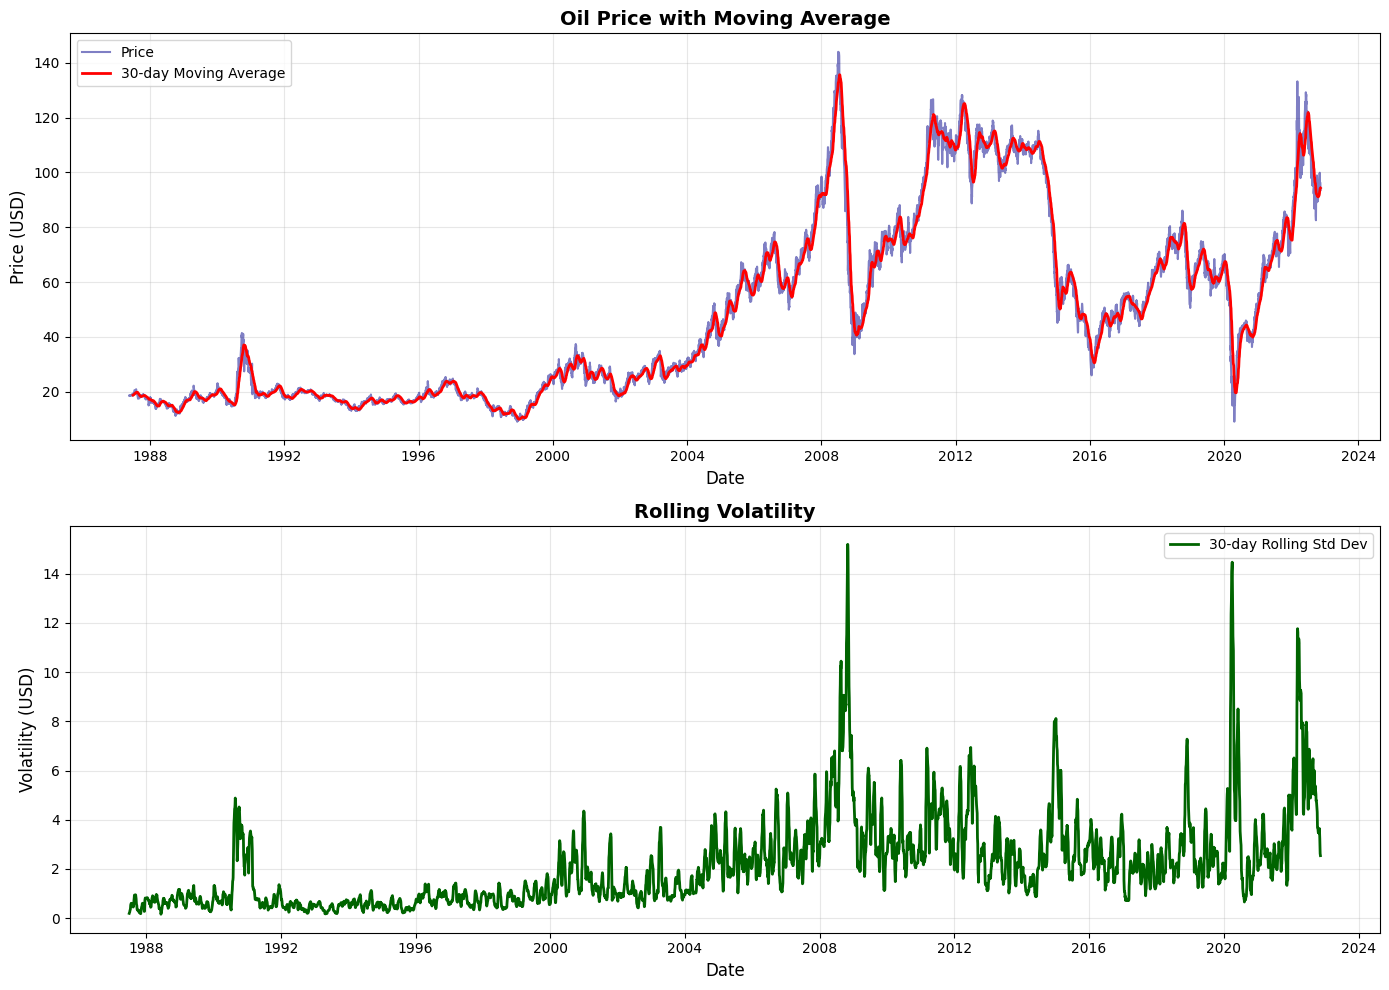

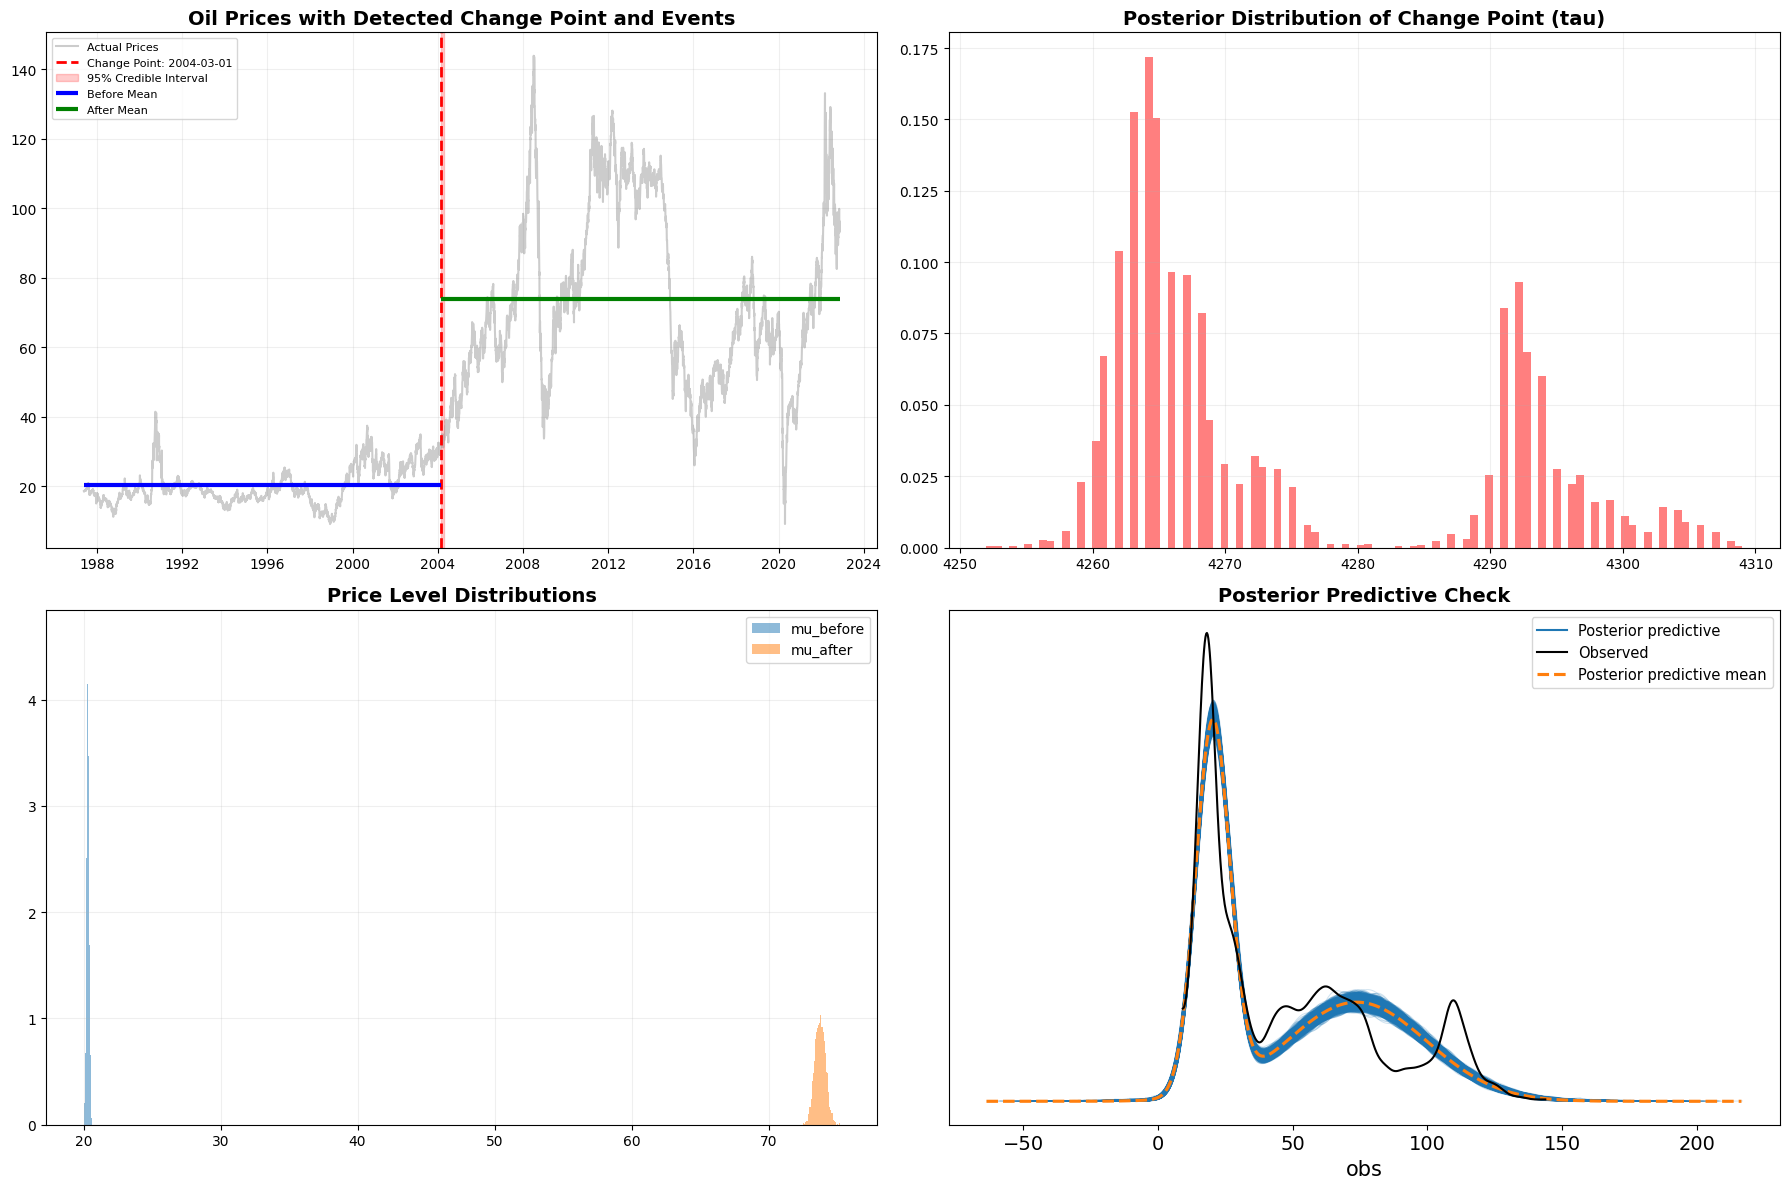

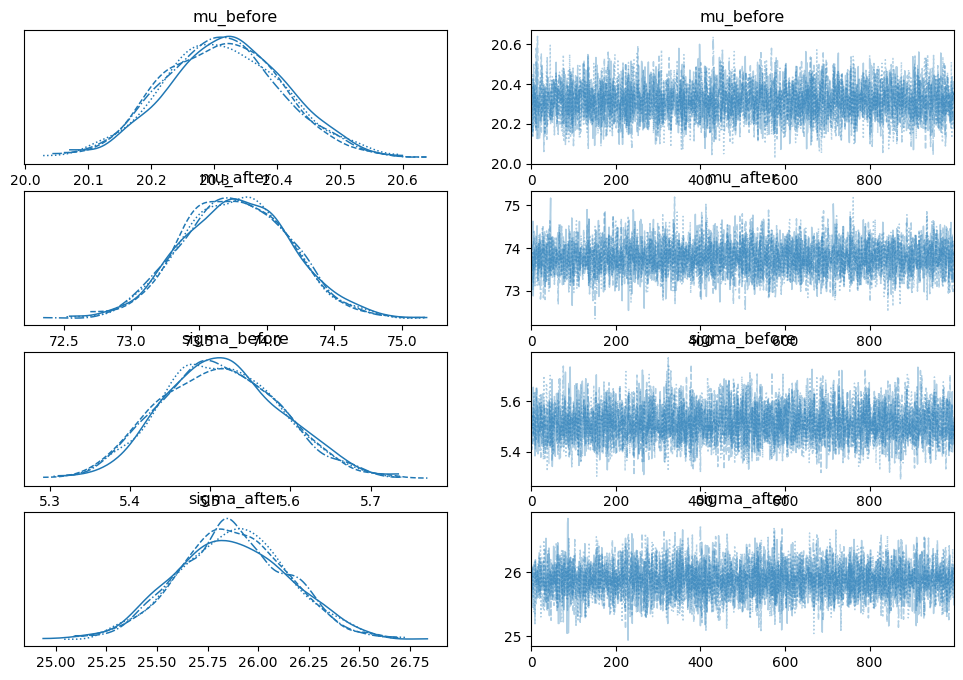

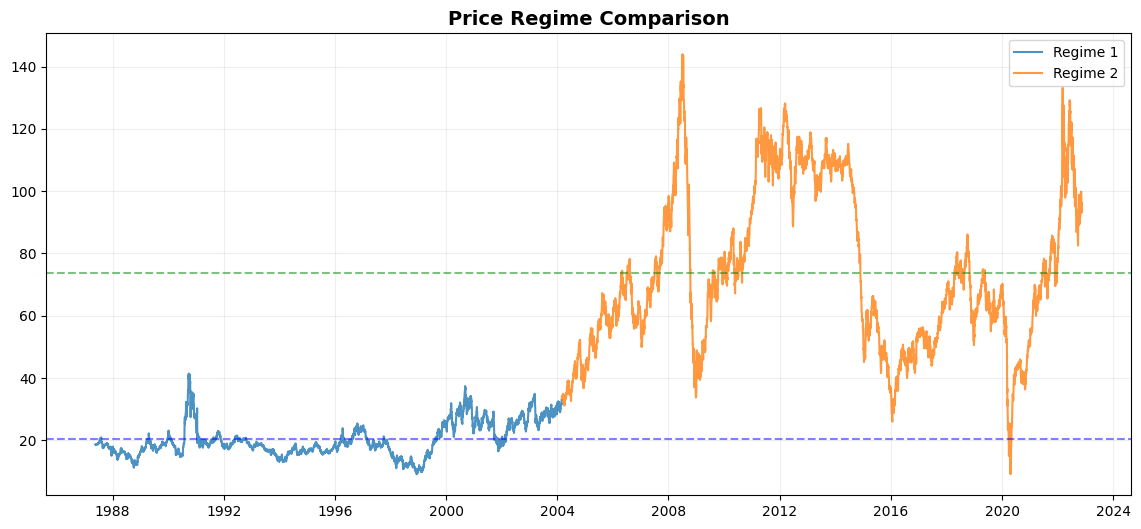


✓ All visualizations saved to: c:\Users\Acer\Documents\KAIM_PROJECT\TEST\oil_price_changepoint\notebooks\..\outputs


In [18]:
# Save all visualizations
print("Saving all visualizations...\n")

# EDA plots
plot_time_series(df_clean, save_path=output_dir / 'eda_time_series.png')
plot_distribution(df_clean, save_path=output_dir / 'eda_distribution.png')
plot_volatility(df_clean, window=30, save_path=output_dir / 'eda_volatility.png')

# Results plots
plot_changepoint_results(
    data_dict['dates'],
    data_dict['oil_prices'],
    results,
    trace,
    save_path=output_dir / 'changepoint_results.png'
)

plot_trace_diagnostics(
    trace,
    save_path=output_dir / 'trace_diagnostics.png'
)

plot_regime_comparison(
    data_dict['dates'],
    data_dict['oil_prices'],
    results,
    save_path=output_dir / 'regime_comparison.png'
)

print("\n✓ All visualizations saved to:", output_dir.absolute())